In [ ]:
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import pandas as pd
import json

with open("../data/explanations_true_gender.json", "r") as f:
    results_formatted = json.load(f)

/Users/savkin/miniconda3/envs/sber_interp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
print(results_formatted[0]["prompts"]["user_prompt"])


Данные клиента:

1. Сэмпл транзакций (Markdown таблица):

Первые 50 транзакций:
|    |   customer_id | дата и время проведения транзакции   |   сумма транзакции | описание типа транзакции (например, покупка, возврат и т.д.)                                     | описание MCC-кода, определяющего категорию торговой точки                                                                                                  |   is_positive |   is_negative |   час проведения транзакции |   минута проведения транзакции |   день недели, когда произошла транзакция |   день месяца транзакции |   флаг, указывающий, была ли транзакция в выходной день |   количество дней, прошедших с последней транзакции этого клиента | weekday_name   |
|---:|--------------:|:-------------------------------------|-------------------:|:-------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------------------------

In [ ]:
texts = [result["completion"]["text"] for result in results_formatted]
labels = [result["gender"] for result in results_formatted]

# Generate embeddings
model = SentenceTransformer('all-MiniLM-L6-v2', device="mps")
embeddings = model.encode(texts)

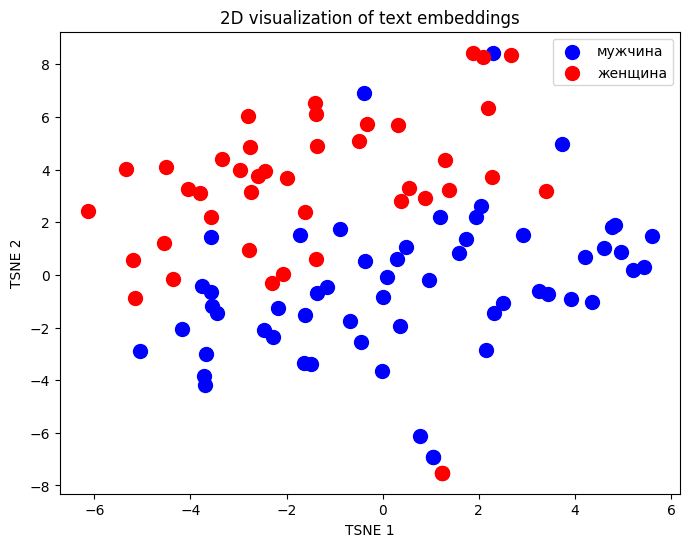

In [26]:
# Reduce to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, init='pca')
emb_2d = tsne.fit_transform(embeddings)

# Create DataFrame for easier plotting
df = pd.DataFrame({
    "x": emb_2d[:,0],
    "y": emb_2d[:,1],
    "label": labels,
    "text": texts
})

# Plot
plt.figure(figsize=(8,6))
for lbl, color in zip(["мужчина", "женщина"], ["blue", "red"]):
    subset = df[df.label == lbl]
    plt.scatter(subset.x, subset.y, label=lbl, color=color, s=100)
    # Optionally add text labels
    # for _, row in subset.iterrows():
    #     plt.text(row.x + 0.1, row.y + 0.1, row.text, fontsize=9)
plt.legend()
plt.title("2D visualization of text embeddings")
plt.xlabel("TSNE 1")
plt.ylabel("TSNE 2")
plt.show()

In [ ]:
print("\n\n".join([f"{i+1}) {text}" for i, text in enumerate(texts)]))